Modules:

In [1]:
import pandas as pd
import time
from google import genai
from google.genai import types
import json
import os
import sys
from tqdm import tqdm
from dotenv import load_dotenv

Config:

In [19]:
# --- CONFIGURATION ---
# Load the API key from your specific .env file
load_dotenv("API_keys.env")
API_KEY = os.getenv("GEMINI_API_KEY_KOBE")
if API_KEY: print("API_KEY loaded succesfully")

# Prompt Technique Toggles
EXAMPLES_ENABLED = False    # 3-shot examples
REASONING_ENABLED = False   # Chain-of-thought reasoning
CONFIDENCE_ENABLED = False  # Confidence score
ROLE_NR = 1                   # Choose the system prompt (role): default = 1
ROLE = {1: "an expert in ESG investment", 
         2: "an expert in classifying posts", 
         3: "a professor of linguistics",
         4: "an academic expert in ESG (Environmental, Social, and Governance) analysis"}[ROLE_NR]

# --- FILES & MODEL ---
MODEL = "Gem2.5p"
MODEL_ID = {"Gem2.5f": "gemini-2.5-flash", "Gem2.5p": "gemini-2.5-pro", "GPT5": "gpt-5"}[MODEL]
OUTPUT_FILE = f"PoC classification_{MODEL}_role{ROLE_NR}{"_examples" if EXAMPLES_ENABLED else ""}{"_reasoning" if REASONING_ENABLED else ""}{"_confidence" if CONFIDENCE_ENABLED else ""}.csv"
INPUT_FILE = "PoC data.csv" if not os.path.exists(OUTPUT_FILE) else OUTPUT_FILE     # Continue with the previous output if output has already been created for this configuration
CATEGORY_FILE = "classification_categories.txt"
EXAMPLES_FILE = f"classification_examples{"_reasoning" if REASONING_ENABLED else ""}{"_confidence" if CONFIDENCE_ENABLED else ""}.txt"

# Script Parameters
TEMPERATURE = 0                       # Strictly deterministic
MAX_POSTS = 20                        # "None" for full analysis
POST_START = 0                       # Index of the post where analysis should start (0 is first post)
CHECKPOINT_INTERVAL = 5              # Save after x posts
SLEEP_TIME = 10                        # Break (in seconds) between API calls: for Google AI free version this should be > 12s, for paid > .01s
RETRIES = 3                             # Amount of retries for 500 / 503 errors

# The 10 official LSEG subcategories
SUBCATEGORIES = [
    "Resource Use", "Emissions", "Innovation", 
    "Workforce", "Human Rights", "Community", "Product Responsibility", 
    "Management", "Shareholders", "CSR Strategy"
]

# Mapping from subcategory to parent category
PARENT_MAP = {
    "Resource Use": "E", "Emissions": "E", "Innovation": "E",
    "Workforce": "S", "Human Rights": "S", "Community": "S", "Product Responsibility": "S",
    "Management": "G", "Shareholders": "G", "CSR Strategy": "G",
    "None": "N"
}

API_KEY loaded succesfully


# Classification algorithm:

In [20]:
client = genai.Client(api_key=API_KEY)

def load_definitions(filepath):
    """Loads ESG definitions from text file. Raises error if file is missing."""
    if not os.path.exists(filepath):
        print(f"CRITICAL ERROR: Definition file '{filepath}' not found.")
        raise FileNotFoundError(f"Missing required file: {filepath}")
    
    with open(filepath, 'r', encoding='utf-8') as f:
        print(filepath, "opened successfully.")
        return f.read()

def load_examples(filepath):
    """Loads few-shot examples from text file. Raises error if file is missing."""
    if not os.path.exists(filepath):
        print(f"CRITICAL ERROR: Examples file '{filepath}' not found.")
        raise FileNotFoundError(f"Missing required file: {filepath}")
        
    with open(filepath, 'r', encoding='utf-8') as f:
        print(filepath, "opened successfully.")
        return f.read()

def build_prompt(post_text, definitions, examples):
    """Dynamically builds the prompt based on configuration."""
    
    # Constructing the dynamic JSON schema description
    schema_fields = ['"Cat_E": "Yes/No"', '"Cat_S": "Yes/No"', '"Cat_G": "Yes/No"', '"Cat_N": "Yes/No"']
    for sub in SUBCATEGORIES:
        clean_sub = sub.replace(" ", "_")
        details = ['"active": "Yes/No"']
        if REASONING_ENABLED: details.append('"reasoning": "string"')
        if CONFIDENCE_ENABLED: details.append('"confidence": float(0-1)')
        schema_fields.append(f'"{clean_sub}": {{{", ".join(details)}}}')

    prompt = f"""
You are {ROLE}.
Your task is to analyze LinkedIn posts and classify them into 10 specific LSEG ESG subcategories.

Definitions of the LSEG ESG subcategories:
{definitions}

Instructions:
1. Determine if the article contains explicit thematic evidence of one or more of the 10 LSEG ESG categories. 
You are identifying the presence of a topic, regardless of whether the information is positive, negative, or neutral. 
Only classify based on explicit evidence. NEVER derive or imply categories.
2. If there is absolutely no concrete evidence for any category, assign "N" as the label and "None" as the sublabel. 
Even if you assign "None", you MUST {"provide a justification explaining why the article is not ESG-relevant and" if REASONING_ENABLED else ""} set all scores to 0. 
Never provide an empty output.
{ "3. Provide a detailed reasoning for every active subcategory classification." if REASONING_ENABLED else "" }
{ "4. Provide a confidence score (0.0 to 1.0) for every classification, representing your level of certainty." if CONFIDENCE_ENABLED else "" }

{ f"Examples:\n{examples}" if EXAMPLES_ENABLED else ""}

Strict Output Format (JSON):
{{
    {", ".join(schema_fields)}
}}

Input (LinkedIn Post):
{post_text}
"""
    return prompt

def get_response_schema():
    """Defines a strict JSON schema to physically prevent syntax errors like trailing commas."""
    properties = {
        "Cat_E": {"type": "STRING", "description": "Yes/No"},
        "Cat_S": {"type": "STRING", "description": "Yes/No"},
        "Cat_G": {"type": "STRING", "description": "Yes/No"},
        "Cat_N": {"type": "STRING", "description": "Yes/No"},
    }
    
    # Define the structure for each subcategory object
    sub_props = {
        "active": {"type": "STRING", "description": "Yes/No"}
    }
    if REASONING_ENABLED:
        sub_props["reasoning"] = {"type": "STRING"}
    if CONFIDENCE_ENABLED:
        sub_props["confidence"] = {"type": "NUMBER"}

    # Add each subcategory to the schema dynamically
    for sub in SUBCATEGORIES:
        clean_sub = sub.replace(" ", "_")
        properties[clean_sub] = {
            "type": "OBJECT",
            "properties": sub_props,
            "required": list(sub_props.keys())
        }
    
    return types.Schema(
        type="OBJECT",
        properties=properties,
        required=list(properties.keys())
    )

def classify_post(post_text, definitions, examples, retries):
    """Sends prompt to Gemini using a strict Response Schema and handles 503 errors."""
    prompt = build_prompt(post_text, definitions, examples)
    
    for attempt in range(retries):
        try:
            response = client.models.generate_content(
                model=MODEL_ID,
                contents=prompt,
                config=types.GenerateContentConfig(
                    temperature=TEMPERATURE,
                    response_mime_type="application/json",
                    response_schema=get_response_schema(), # This is the magic fix
                )
            )
            # The schema ensures the text is valid JSON
            return json.loads(response.text)
            
        except Exception as e:
            # Check for 503 (Service Unavailable) or 500 (Internal Error)
            if "503" in str(e) or "500" in str(e):
                print(f"\n[Attempt {attempt + 1}] Server busy (503/500). Retrying in {5 * (attempt + 1)}s...")
                time.sleep(5 * (attempt + 1))
                continue
            
            # For other errors (like auth or quota), return immediately
            return {"error": str(e)}
            
    return {"error": "Maximum retries reached. Google service is currently unavailable."}

def main():
    # 1. Verification of required files
    try:
        definitions = load_definitions(CATEGORY_FILE)
        examples = load_examples(EXAMPLES_FILE)
    except FileNotFoundError:
        sys.exit(1)

    if not os.path.exists(INPUT_FILE):
        print(f"Error: Input file '{INPUT_FILE}' not found.")
        return

    # 2. Load Data
    df = pd.read_csv(INPUT_FILE)
    print(INPUT_FILE, "opened succesfully")
    # Expected columns: Company, Date, Link, Text
    text_col = "Text" 

    # 3. Initialize Columns
    # Ensure main category columns exist
    for cat in ["Cat_E", "Cat_S", "Cat_G", "Cat_N"]:
        if cat not in df.columns: df[cat] = None
        
    # Ensure subcategory columns exist
    for sub in SUBCATEGORIES:
        clean_sub = sub.replace(" ", "_")
        cols = [f"{clean_sub}_active"]
        if REASONING_ENABLED: cols.append(f"{clean_sub}_reasoning")
        if CONFIDENCE_ENABLED: cols.append(f"{clean_sub}_confidence")
        
        for col in cols:
            if col not in df.columns: df[col] = None

    # Calculate range
    end_index = len(df)
    if MAX_POSTS is not None:
        end_index = min(POST_START + MAX_POSTS, len(df))

    print(f"Processing posts from index {POST_START} to {end_index}...")

    # 4. Processing Loop
    for index in tqdm(range(POST_START, end_index), desc="Classifying"):
        # Skip if already successfully processed
        if pd.notna(df.at[index, 'Cat_E']) and "ERROR" not in str(df.at[index, 'Cat_N']):
            continue

        post_content = df.at[index, text_col]
        result = classify_post(post_content, definitions, examples, RETRIES)

        if "error" in result:
            df.at[index, 'Cat_N'] = "ERROR: " + result["error"]
        else:
            # Map Main Categories
            for cat in ["Cat_E", "Cat_S", "Cat_G", "Cat_N"]:
                df.at[index, cat] = result.get(cat, "No")

            # Map Subcategories directly
            for sub in SUBCATEGORIES:
                clean_sub = sub.replace(" ", "_")
                sub_data = result.get(clean_sub, {})
                
                df.at[index, f"{clean_sub}_active"] = sub_data.get("active", "No")
                if REASONING_ENABLED:
                    df.at[index, f"{clean_sub}_reasoning"] = sub_data.get("reasoning", "")
                if CONFIDENCE_ENABLED:
                    df.at[index, f"{clean_sub}_confidence"] = sub_data.get("confidence", 0.0)

        # Checkpoint
        if (index + 1) % CHECKPOINT_INTERVAL == 0:
            df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
        
        time.sleep(SLEEP_TIME)

    # Final Save
    df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
    print(f"\nProcessing complete! Results saved to {OUTPUT_FILE}")

if __name__ == "__main__":
    main()

classification_categories.txt opened successfully.
classification_examples.txt opened successfully.
PoC data.csv opened succesfully
Processing posts from index 0 to 20...


Classifying:   0%|          | 0/20 [00:00<?, ?it/s]


[Attempt 1] Server busy (503/500). Retrying in 5s...


Classifying:  10%|█         | 2/20 [00:48<07:04, 23.61s/it]


[Attempt 1] Server busy (503/500). Retrying in 5s...

[Attempt 2] Server busy (503/500). Retrying in 10s...


...


[Attempt 1] Server busy (503/500). Retrying in 5s...

[Attempt 2] Server busy (503/500). Retrying in 10s...


Classifying:  85%|████████▌ | 17/20 [07:47<01:28, 29.41s/it]


[Attempt 1] Server busy (503/500). Retrying in 5s...

[Attempt 2] Server busy (503/500). Retrying in 10s...


Classifying: 100%|██████████| 20/20 [09:16<00:00, 27.83s/it]


Processing complete! Results saved to PoC classification_Gem2.5p_role1.csv


# Classification validation & performance:

In [ ]:
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, cohen_kappa_score, hamming_loss
import warnings

In [ ]:
# --- CONFIGURATION ---
EXAMPLES = False  # True if classification was executed including reasoning
REASONING = False  # True if classification was executed including reasoning
CONFIDENCE = False  # True if classification was executed including confidence scores
ROLE_NR = 1         # Role number for the system prompt with which classification was executed
MODEL = "Gem2.5f"   # Model ID for the model with which classification was executed
MULTISTAGE = 2

# --- FILES ---
PREDICTIONS_FILE = f"PoC classification{f"_multi{MULTISTAGE}" if MULTISTAGE in (2, 3) else ""}_{MODEL}_role{ROLE_NR}{"_examples" if EXAMPLES else ""}{"_reasoning" if REASONING else ""}{"_confidence" if CONFIDENCE else ""}.csv"
GROUND_TRUTH_FILE = "PoC clsf ground truth.csv"  # Manually classified csv
OUTPUT_METRICS_CSV = f"PoC clsf validation{f"_multi{MULTISTAGE}" if MULTISTAGE in (2, 3) else ""}_{MODEL}_role{ROLE_NR}{"_examples" if EXAMPLES else ""}{"_reasoning" if REASONING else ""}{"_confidence" if CONFIDENCE else ""}.csv"
OUTPUT_VISUALIZATION = f"PoC cslf confusion matrices{f"_multi{MULTISTAGE}" if MULTISTAGE in (2, 3) else ""}_{MODEL}_role{ROLE_NR}{"_examples" if EXAMPLES else ""}{"_reasoning" if REASONING else ""}{"_confidence" if CONFIDENCE else ""}.png"

CATEGORIES = ["Cat_E", "Cat_S", "Cat_G", "Cat_N"]
SUBCATEGORIES = [
    "Resource_Use", "Emissions", "Innovation", 
    "Workforce", "Human_Rights", "Community", "Product_Responsibility", 
    "Management", "Shareholders", "CSR_Strategy"
]

Visual summary saved as: PoC cslf confusion matrices.png

--- VALIDATION SUMMARY ---
Average Accuracy (Micro): 0.8679
Hamming Loss: 0.1321
Micro F1: 0.8679
Macro F1: 0.7274
Detailed results saved in: PoC clsf validation_role1.csv


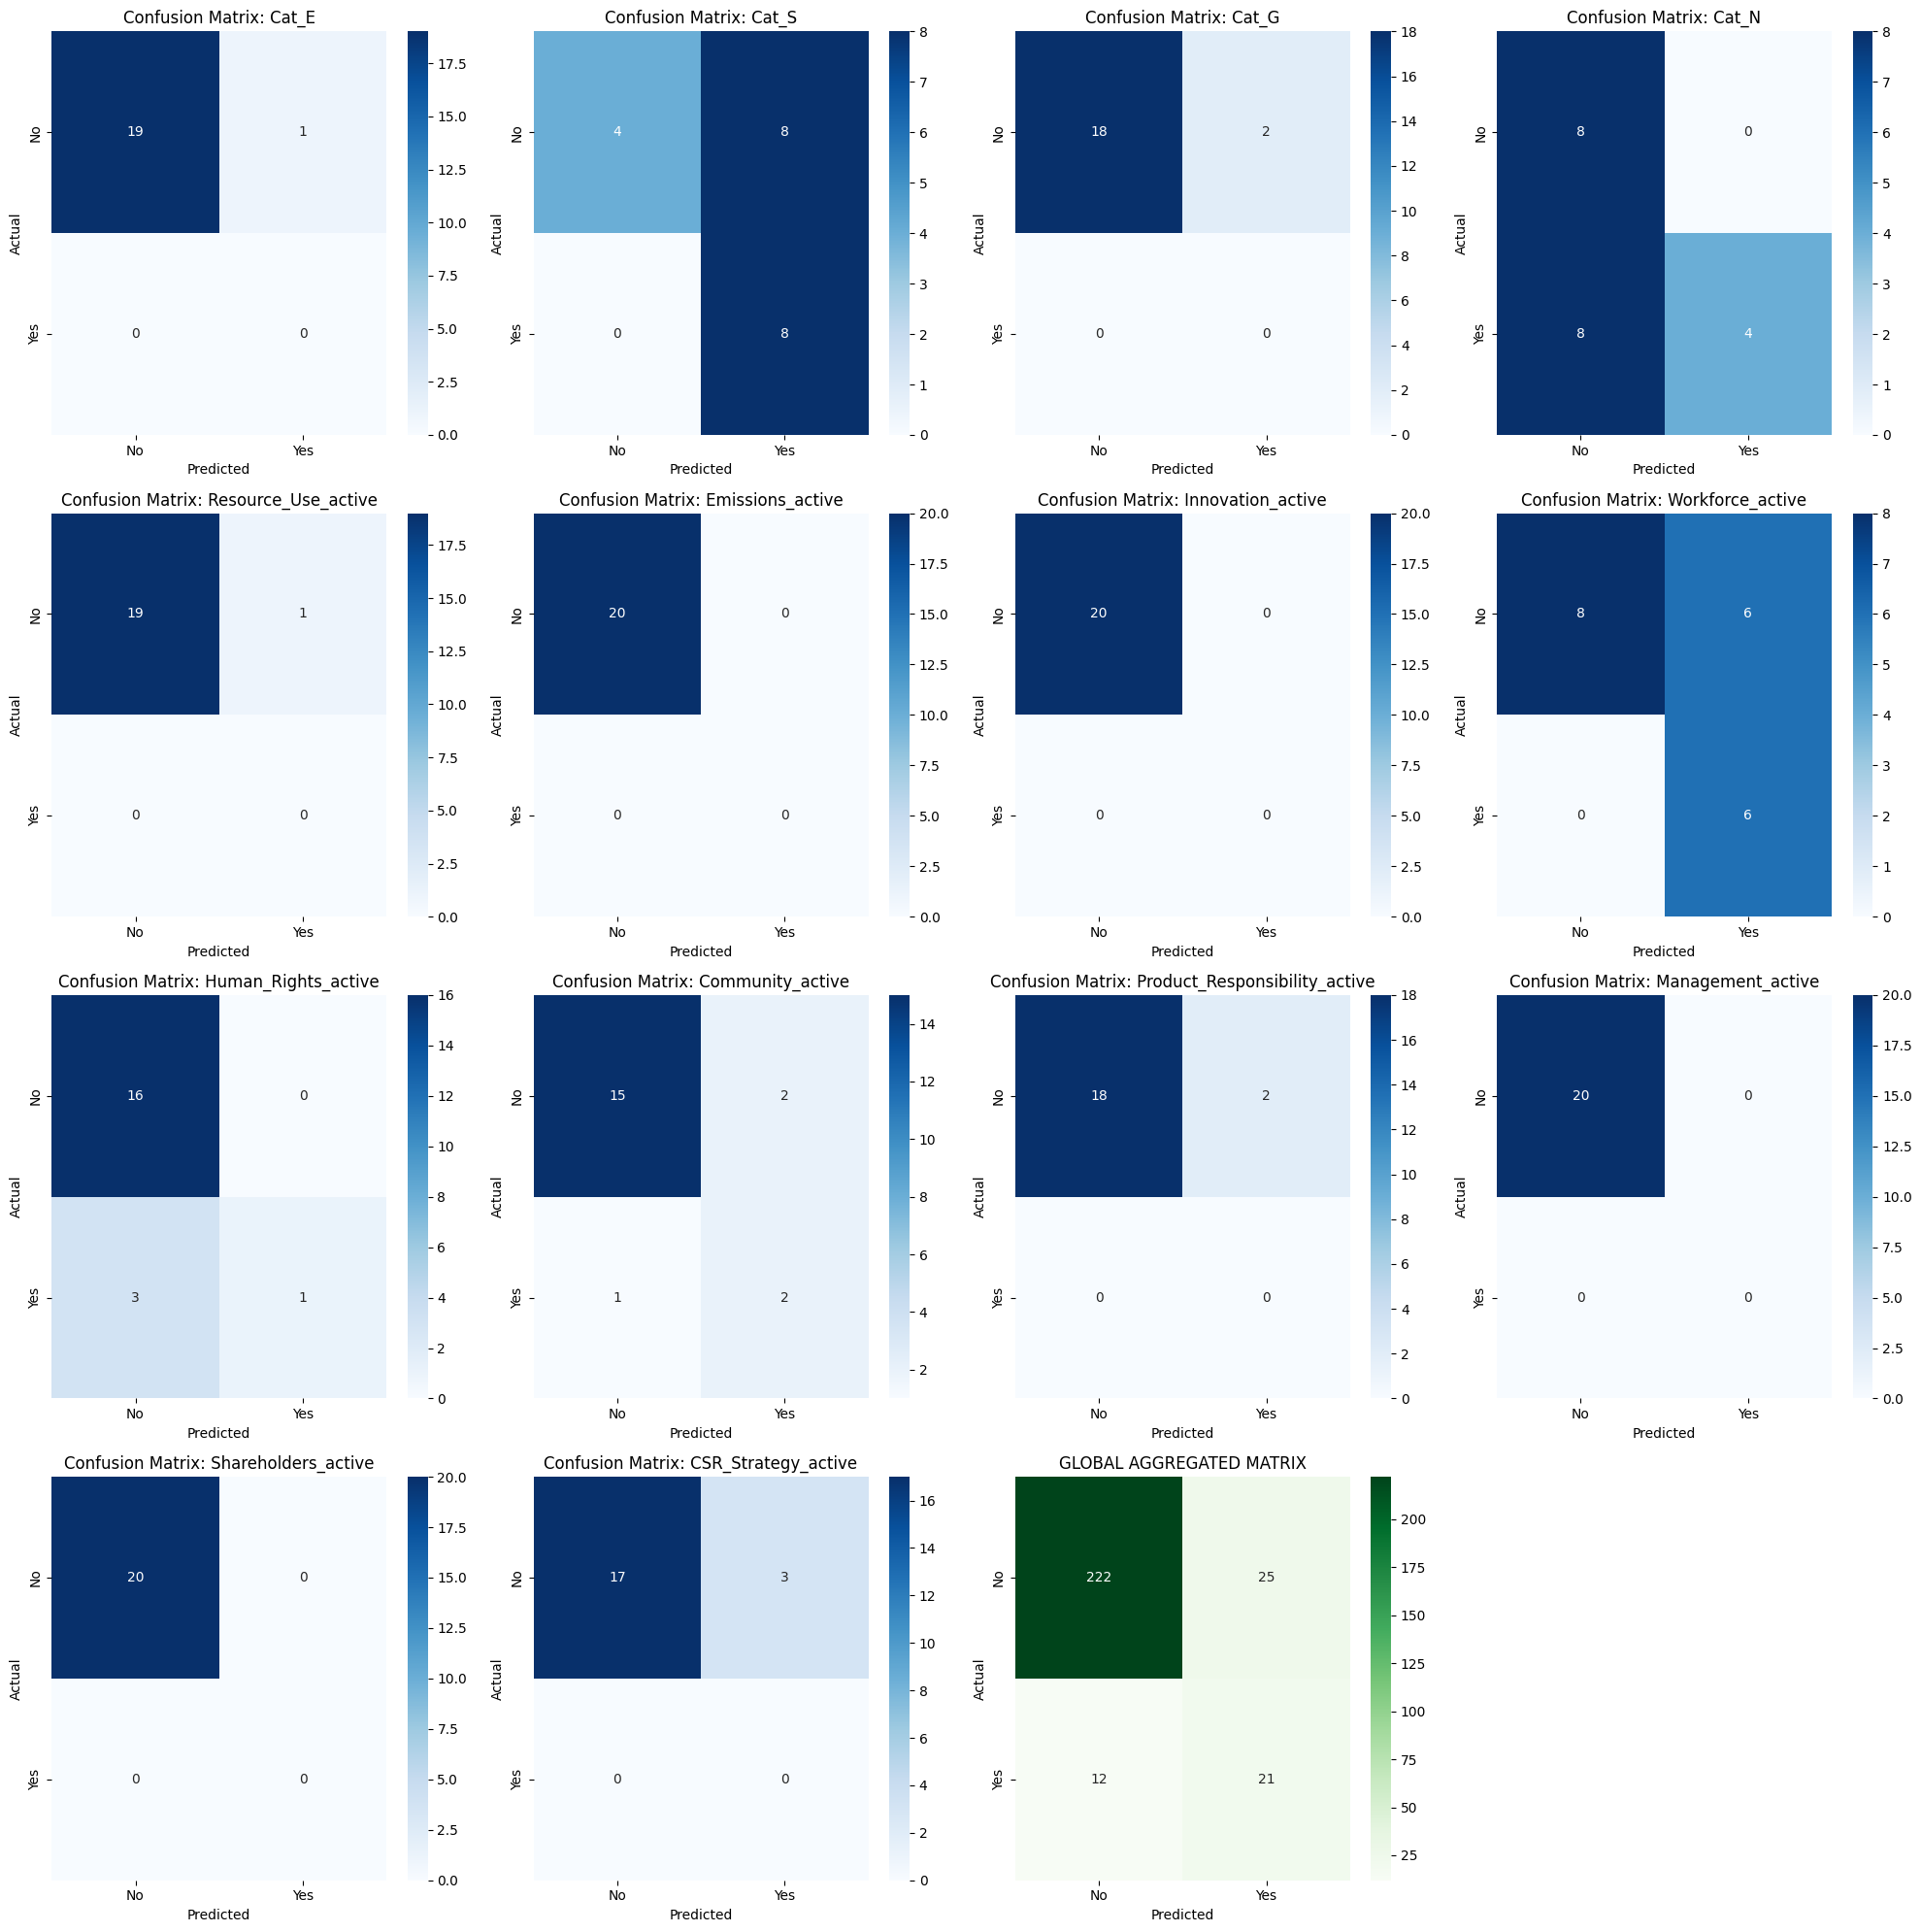

In [16]:
# Main script

def load_and_prepare_data():
    """Loads the files and aligns them using the 'Link' column."""
    if not os.path.exists(PREDICTIONS_FILE) or not os.path.exists(GROUND_TRUTH_FILE):
        print(f"ERROR: One of the input files is missing: {PREDICTIONS_FILE} or {GROUND_TRUTH_FILE}")
        sys.exit(1)

    df_pred = pd.read_csv(PREDICTIONS_FILE)
    df_true = pd.read_csv(GROUND_TRUTH_FILE)

    # Clean column names to avoid whitespace issues
    df_pred.columns = df_pred.columns.str.strip()
    df_true.columns = df_true.columns.str.strip()

    # Align data by sorting by Link
    df_pred = df_pred.sort_values(by="Link").reset_index(drop=True)
    df_true = df_true.sort_values(by="Link").reset_index(drop=True)

    if len(df_pred) != len(df_true):
        print(f"WARNING: Row counts do not match ({len(df_pred)} vs {len(df_true)}). Performing inner join...")
        combined = pd.merge(df_true, df_pred, on="Link", suffixes=('_true', '_pred'))
        return combined
    
    return pd.concat([df_true.add_suffix('_true'), df_pred.add_suffix('_pred')], axis=1)

def get_binary_values(series):
    """Converts 'Yes'/'No' or 1/0 values to binary integers."""
    return series.astype(str).str.strip().str.capitalize().map({'Yes': 1, 'No': 0, '1': 1, '0': 0}).fillna(0).astype(int)

def find_column(df_cols, target):
    """Finds a column name in a list regardless of case sensitivity."""
    for col in df_cols:
        if col.lower() == target.lower():
            return col
    return None

def main():
    # Ignore specific RuntimeWarnings for Kappa calculation in single-class cases
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in scalar divide")
    
    data = load_and_prepare_data()
    
    results = []
    all_true_labels = []
    all_pred_labels = []

    # Combine main categories and subcategories for the loop
    target_bases = CATEGORIES + [f"{sub}_active".replace(" ", "_") for sub in SUBCATEGORIES]
    
    # Prepare visualization (+1 for the Global Matrix)
    total_plots = len(target_bases) + 1
    n_cols = 4
    n_rows = (total_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = axes.flatten()

    processed_count = 0
    for i, base_name in enumerate(target_bases):
        # Look for the true and predicted versions in the combined dataframe
        true_col = find_column(data.columns, f"{base_name}_true")
        pred_col = find_column(data.columns, f"{base_name}_pred")

        if not true_col or not pred_col:
            print(f"Skipping column {base_name}: Not found in both datasets.")
            continue

        y_true = get_binary_values(data[true_col])
        y_pred = get_binary_values(data[pred_col])

        all_true_labels.append(y_true)
        all_pred_labels.append(y_pred)

        # Calculate counts - explicitly provide labels to avoid shape errors
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        
        # Calculate scores
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        # Robust Kappa calculation to avoid RuntimeWarnings
        # Kappa is undefined if one rater uses only one class or if there is no variance
        if len(np.unique(y_true)) < 2 and len(np.unique(y_pred)) < 2:
            kappa = 1.0 if y_true.iloc[0] == y_pred.iloc[0] else 0.0
        else:
            try:
                kappa = cohen_kappa_score(y_true, y_pred, labels=[0, 1])
                if np.isnan(kappa): kappa = 0.0
            except:
                kappa = 0.0

        results.append({
            "Category": base_name,
            "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
            "Ground_Truth_Yes_Count": int(sum(y_true)),
            "LLM_Classifier_Yes_Count": int(sum(y_pred)),
            "Total_Posts": len(y_true),
            "Accuracy": acc,
            "F1_Score": f1,
            "Cohen_Kappa": kappa
        })

        # Visualization for specific category
        sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt='d', ax=axes[i], cmap='Blues', 
                    xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
        axes[i].set_title(f"Confusion Matrix: {base_name}")
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("Actual")
        processed_count += 1

    # --- ADD GLOBAL AGGREGATED CONFUSION MATRIX ---
    if all_true_labels:
        y_true_all = np.array(all_true_labels).flatten()
        y_pred_all = np.array(all_pred_labels).flatten()
        
        g_tn, g_fp, g_fn, g_tp = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1]).ravel()
        
        sns.heatmap([[g_tn, g_fp], [g_fn, g_tp]], annot=True, fmt='d', ax=axes[processed_count], cmap='Greens', 
                    xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
        axes[processed_count].set_title("GLOBAL AGGREGATED MATRIX")
        axes[processed_count].set_xlabel("Predicted")
        axes[processed_count].set_ylabel("Actual")
        processed_count += 1

        # Calculate Global Stats
        h_loss = hamming_loss(np.array(all_true_labels).T, np.array(all_pred_labels).T)
        micro_f1 = f1_score(y_true_all, y_pred_all, average='micro', zero_division=0)
        macro_f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
        avg_acc = accuracy_score(y_true_all, y_pred_all)

        df_results = pd.DataFrame(results)
        
        # Create summary row
        summary_row = pd.DataFrame([{
            "Category": "GLOBAL_SUMMARY_METRICS",
            "Accuracy": avg_acc,
            "F1_Score": micro_f1,
            "Cohen_Kappa": macro_f1, # Labeling column contextually for the summary
            "TP": int(g_tp), "FP": int(g_fp), "TN": int(g_tn), "FN": int(g_fn),
            "Ground_Truth_Yes_Count": int(sum(y_true_all)),
            "LLM_Classifier_Yes_Count": int(sum(y_pred_all)),
            "Note": f"Hamming Loss: {h_loss:.4f} | Macro F1: {macro_f1:.4f}"
        }])
        
        # Combine and save
        final_df = pd.concat([df_results, summary_row], ignore_index=True)
        final_df.to_csv(OUTPUT_METRICS_CSV, index=False, encoding='utf-8-sig')
        
        # Cleanup empty plots
        for j in range(processed_count, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.savefig(OUTPUT_VISUALIZATION)
        
        print(f"Visual summary saved as: {OUTPUT_VISUALIZATION}")
        print("\n--- VALIDATION SUMMARY ---")
        print(f"Average Accuracy (Micro): {avg_acc:.4f}")
        print(f"Hamming Loss: {h_loss:.4f}")
        print(f"Micro F1: {micro_f1:.4f}")
        print(f"Macro F1: {macro_f1:.4f}")
        print(f"Detailed results saved in: {OUTPUT_METRICS_CSV}")
    else:
        print("ERROR: No data was processed. Check your column names and file structure.")

if __name__ == "__main__":
    main()

# Model comparison

In [ ]:
# Skip this if the classification script has already been executed (redundant)

import pandas as pd
import sys
import os

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

Filtering: Excluding files with 'doubts' in the name.
Found 5 validation files. Extracting metrics...

--- PERFORMANCE RANKING (By Micro F1) ---
                                   Model  Micro F1  Macro F1  Hamming Loss
                              Clsf_role1  0.867857  0.727361        0.1321
                     Clsf_role1_examples  0.867857  0.732983        0.1321
                     Clsf_role2_examples  0.864286  0.728544        0.1357
           Clsf_role1_examples_reasoning  0.839286  0.687926        0.1607
Clsf_role1_examples_reasoning_confidence  0.821429  0.669031        0.1786

WINNER: Clsf_role1
Top Micro F1: 0.8679

Comparison graph saved as: model_performance_comparison.png


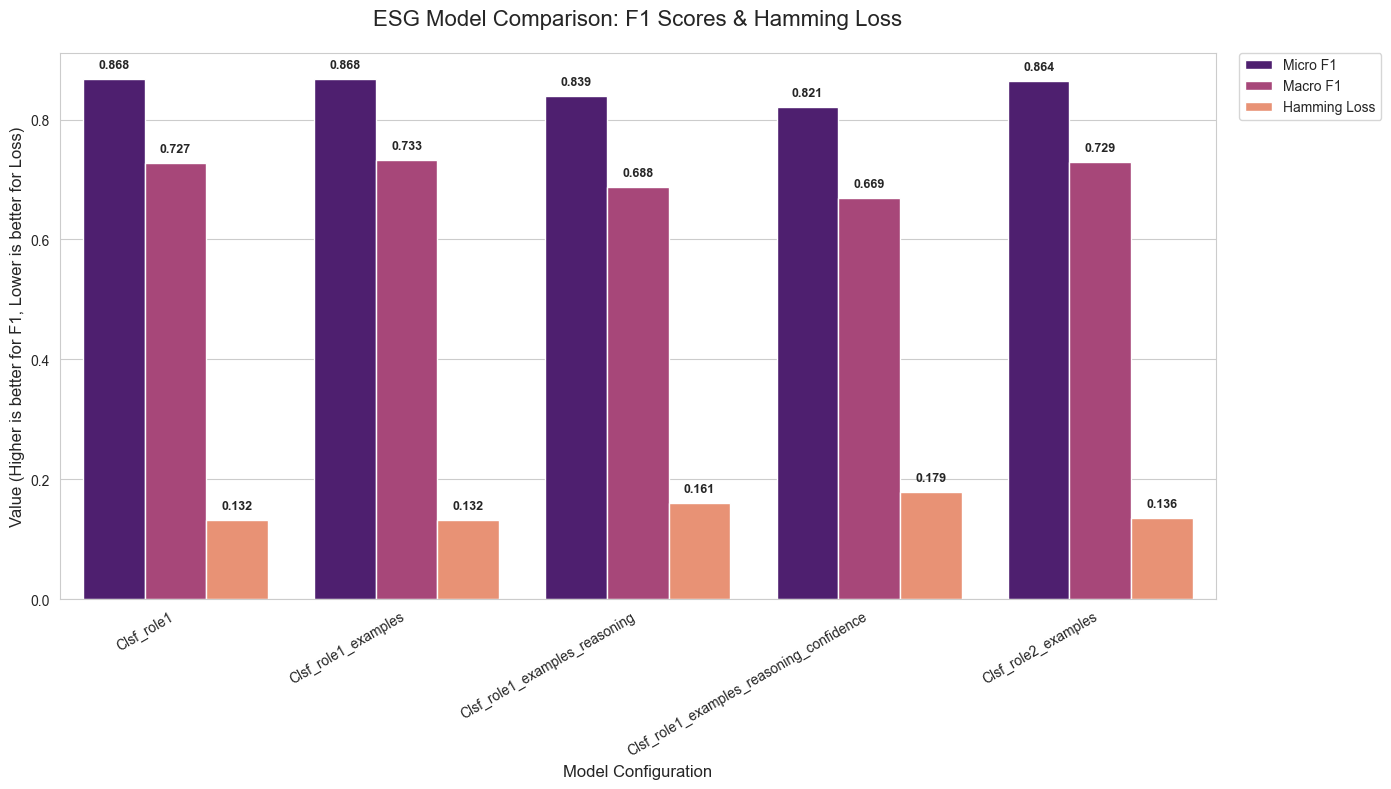

In [19]:
# --- CONFIGURATION ---
# The script will look for files matching this pattern in the current directory
FILE_PATTERN = r"PoC clsf validation.*\.csv"
COMPARISON_OUTPUT_IMAGE = "model_performance_comparison.png"

# Toggle to include or exclude files containing "doubts"
INCLUDE_DOUBTS = False 

def extract_global_metrics(filepath):
    """
    Extracts global metrics from the validation CSV.
    The script looks for the 'GLOBAL_SUMMARY_METRICS' row.
    """
    try:
        df = pd.read_csv(filepath)
        # Find the summary row
        summary = df[df['Category'] == 'GLOBAL_SUMMARY_METRICS']
        
        if summary.empty:
            print(f"Warning: No GLOBAL_SUMMARY_METRICS found in {filepath}. Skipping.")
            return None
        
        # Extract the metrics
        # In the validation script summary row:
        # F1_Score = Micro F1
        # Cohen_Kappa = Macro F1 (repurposed column)
        
        f1_micro = summary['F1_Score'].values[0]
        f1_macro = summary['Cohen_Kappa'].values[0] 
        
        # Extract Hamming Loss from the 'Note' column using regex
        note = str(summary['Note'].values[0])
        h_loss_match = re.search(r"Hamming Loss: ([\d\.]+)", note)
        h_loss = float(h_loss_match.group(1)) if h_loss_match else None
        
        # Clean up filename for the legend
        display_name = os.path.basename(filepath).replace(".csv", "").replace("PoC clsf validation", "Clsf")
        
        return {
            "Model": display_name,
            "Micro F1": f1_micro,
            "Macro F1": f1_macro,
            "Hamming Loss": h_loss
        }
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

def main():
    # 1. Find all relevant files
    all_files = [f for f in os.listdir('.') if re.match(FILE_PATTERN, f)]
    
    # 2. Filter out "doubts" if disabled
    if not INCLUDE_DOUBTS:
        all_files = [f for f in all_files if "doubts" not in f.lower()]
        print("Filtering: Excluding files with 'doubts' in the name.")

    if not all_files:
        print("No validation files found matching the pattern and filters.")
        return

    print(f"Found {len(all_files)} validation files. Extracting metrics...")

    # 3. Extract metrics
    comparison_data = []
    for file in all_files:
        metrics = extract_global_metrics(file)
        if metrics:
            comparison_data.append(metrics)

    if not comparison_data:
        print("No valid global metrics could be extracted.")
        return

    df_comp = pd.DataFrame(comparison_data)

    # 4. Determine the best model (using Micro F1 as the primary key)
    best_model_idx = df_comp['Micro F1'].idxmax()
    best_model = df_comp.loc[best_model_idx]
    
    print("\n--- PERFORMANCE RANKING (By Micro F1) ---")
    print(df_comp.sort_values(by="Micro F1", ascending=False).to_string(index=False))
    
    print(f"\nWINNER: {best_model['Model']}")
    print(f"Top Micro F1: {best_model['Micro F1']:.4f}")

    # 5. Visualization
    # Reshape for plotting (Melt)
    df_melted = df_comp.melt(id_vars="Model", var_name="Metric", value_name="Score")

    plt.figure(figsize=(14, 8))
    sns.set_style("whitegrid")
    
    # Create the plot
    ax = sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="magma")
    
    plt.title("ESG Model Comparison: F1 Scores & Hamming Loss", fontsize=16, pad=20)
    plt.ylabel("Value (Higher is better for F1, Lower is better for Loss)", fontsize=12)
    plt.xlabel("Model Configuration", fontsize=12)
    plt.xticks(rotation=30, ha='right')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    
    # Add values on top of bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.3f}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        xytext=(0, 10), 
                        textcoords='offset points',
                        fontsize=9,
                        fontweight='bold')

    plt.tight_layout()
    plt.savefig(COMPARISON_OUTPUT_IMAGE)
    print(f"\nComparison graph saved as: {COMPARISON_OUTPUT_IMAGE}")

if __name__ == "__main__":
    main()